In [1]:
from jax import grad, vmap, jit
import jax.numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline 

In [2]:
df = pd.read_csv('data/prices.csv')

In [3]:
df.columns

Index(['date', 'price_supplier_a_dollars_per_item',
       'price_supplier_b_dollars_per_item'],
      dtype='str')

In [4]:
prices_A = df.price_supplier_a_dollars_per_item
prices_B = df.price_supplier_b_dollars_per_item
prices_A = np.array(prices_A).astype('float32')
prices_B = np.array(prices_B).astype('float32')

In [5]:
prices_A, prices_B

(Array([104., 108., 101., 104., 102., 105., 114., 102., 105., 101., 109.,
        103.,  93.,  98.,  92.,  97.,  96.,  94.,  97.,  93.,  99.,  93.,
         98.,  94.,  93.,  92.,  96.,  98.,  98.,  93.,  97., 102., 103.,
        100., 100., 104., 100., 103., 104., 101., 102., 100., 102., 108.,
        107., 107., 103., 109., 108., 108.], dtype=float32),
 Array([ 76.,  76.,  84.,  79.,  81.,  84.,  90.,  93.,  93.,  99.,  98.,
         96.,  94., 104., 101., 102., 104., 106., 105., 103., 106., 104.,
        113., 115., 114., 124., 119., 115., 112., 111., 106., 107., 108.,
        108., 102., 104., 101., 101., 100., 103., 106., 100.,  97.,  98.,
         90.,  92.,  92.,  99.,  94.,  91.], dtype=float32))

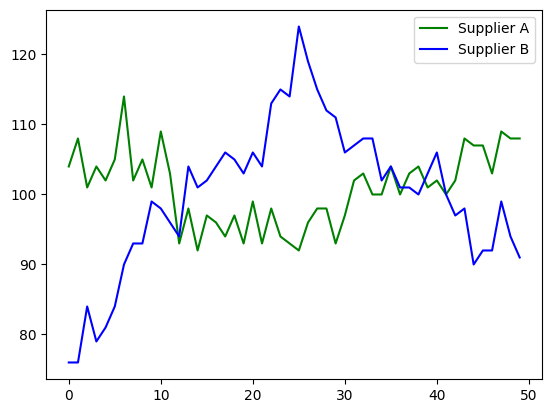

In [6]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
plt.plot(prices_A, 'g', label="Supplier A")
plt.plot(prices_B, 'b', label="Supplier B")
plt.legend()

plt.show()

# 1.1 - Description of the Problem

Your Company is aiming to minimize production costs of some goods. During the production process, an essential product P is used, which can be supplied from one of two partners - supplier A and supplier B. Your consultants requested the historical prices of product P from both suppliers A and B, which were provided as monthly averages for the period from February 2018 to March 2020.

Preparing Company Budget for the coming twelve months period, your plan is to purchase the same amount of product P monthly. Choosing the supplier, you noticed, that there were some periods in the past, when it would be more profitable to use supplier A (the prices of product P were lower), and other periods to work with supplier B. For the Budget model you can set some percentage of the goods to be purchased from supplier A (e.g. 60%) and the remaining part from supplier B (e.g. 40%), but this split should be kept consistent for the whole of the twelve months period. The Budget will be used in preparation for the contract negotiations with both suppliers.

Based on the historical prices, is there a particular percentage which will be more profitable to supply from Company A, and the remaining part from Company B? Or maybe it does not matter and you can work just with one of the suppliers?


# 1.2 - Mathematical Statement of the Problem

Denoting prices of the product P from Company A and Company B as $p_A$ (USD) and $p_B$ (USD) respectively, and the volume of the product to be supplied per month as $n$ (units), the total cost in USD is:

$$f\left(\omega\right) = p_A \omega \,n+ p_B \left(1 - \omega\right) n,$$

where $0\leq\omega\leq1$ is the parameter. If $\omega = 1$, all goods will be supplied from Company A, and if $\omega = 0$, from Company B. In case of $0<\omega<1$, some percentage will be allocated to both. 

As it is planned to keep the volume $n$ constant over the next twelve months, in the mathematical model the common approach is to put $n = 1$. You can do this, because nothing depends on the volume and the end result will be the same. Now the total cost will be simpler:

$$f\left(\omega\right) = p_A \omega+ p_B \left(1 - \omega\right) \tag{1}$$

Obviously, you do not know the future prices $p_A$ and $p_B$, only historical values (prices $\{p_A^1, \cdots, p_A^k\}$ and $\{p_B^1, \cdots, p_B^k\}$ for $k$ months). And historically there were various periods of time when it was better to take $\omega = 1$ ($p_A^i < p_B^i$) or $\omega = 0$ ($p_A^i >p_B^i$). Is it possible now to choose some $\omega$ value that would provide some evidence of minimum costs in the future?


# 1.3 - Solution Approach

This is a standard **portfolio management** (investment) problem well known in statistics, where based on the historical prices you need to make investment decision to maximize profit (minimize costs). Since statistics has not been covered in this Course, you do not need to understand the details about the function $\mathcal{L}\left(\omega\right)$ (called **loss function**) to minimize, explained in the next paragraph.

The approach is to calculate $f\left(\omega\right)$ for each of the historical prices $p_A^i$ and $p_B^i$, $f^i\left(\omega\right)=p_A^i \omega+ p_B^i \left(1 - \omega\right)$. Then take an average of those values, $\overline{f\left (\omega\right)}=\text{mean}\left(f^i\left(\omega\right)\right) = \frac{1}{k}\sum_{i=1}^{k}f^i\left(\omega\right)$ and look for such value of $\omega$ which makes $f^i\left(\omega\right)$ as "stable" as possible - varying as little as possible from the average $\overline{f\left (\omega\right)}$. This means that you would want to minimize the sum of the differences $\left(f^i \left(\omega\right) -  \overline{f\left (\omega\right)}\right)$. As the differences can be negative or positive, a common approach is to take the squares of those and take an average of the squares:

$$\mathcal{L}\left(\omega\right) = \frac{1}{k}\sum_{i=1}^{k}\left(f^i \left(\omega\right) -  \overline{f\left (\omega\right)}\right)^2\tag{2}$$

In statistics $\mathcal{L}\left(\omega\right)$ is called a variance of $\{f^1 \left(\omega\right), \cdots , f^k \left(\omega\right)\}$. The aim is to minimize the variance $\mathcal{L}\left(\omega\right)$, where $\omega\in\left[0, 1\right]$. Again, do not worry if you do not understand deeply why particularly this function $\mathcal{L}\left(\omega\right)$ was chosen. You might think if it is logical to minimize an average $\overline{f\left (\omega\right)}$, but [risk management](https://www.thebalancemoney.com/minimum-variance-portfolio-overview-4155796#:~:text=A%20minimum%20variance%20portfolio%20is,other%20out%20when%20held%20together.) theory states that in this problem variance needs to be optimized.

Statistical theory shows that there is an $\omega\in\left[0, 1\right]$ value which minimizes function $\mathcal{L}\left(\omega\right)$ and it can be found using some properties of the datasets $\{p_A^1, \cdots, p_A^k\}$ and $\{p_B^1, \cdots, p_B^k\}$. However, as this is not a Course about statistics, the example is taken to illustrate an optimization problem of one variable based on some dataset. It is a chance for you to check your understanding and practice this week material. 

Now let's upload a dataset and explore if it is possible to find a minimum point for the corresponding function $\mathcal{L}\left(\omega\right)$.


In [7]:
def f_of_omega(omega, pA, pB):
    f = pA*omega + pB * (1-omega)
    return f

def L_of_omega(omega, pA, pB):
    return 1/len(f_of_omega(omega, pA, pB)) * np.sum((f_of_omega(omega, pA, pB) - np.mean(f_of_omega(omega, pA, pB)))**2)

In [8]:
prices_A, prices_B

(Array([104., 108., 101., 104., 102., 105., 114., 102., 105., 101., 109.,
        103.,  93.,  98.,  92.,  97.,  96.,  94.,  97.,  93.,  99.,  93.,
         98.,  94.,  93.,  92.,  96.,  98.,  98.,  93.,  97., 102., 103.,
        100., 100., 104., 100., 103., 104., 101., 102., 100., 102., 108.,
        107., 107., 103., 109., 108., 108.], dtype=float32),
 Array([ 76.,  76.,  84.,  79.,  81.,  84.,  90.,  93.,  93.,  99.,  98.,
         96.,  94., 104., 101., 102., 104., 106., 105., 103., 106., 104.,
        113., 115., 114., 124., 119., 115., 112., 111., 106., 107., 108.,
        108., 102., 104., 101., 101., 100., 103., 106., 100.,  97.,  98.,
         90.,  92.,  92.,  99.,  94.,  91.], dtype=float32))

In [9]:
# omega = 0, use 100% from supplier B
f_of_omega(0, prices_A, prices_B)

Array([ 76.,  76.,  84.,  79.,  81.,  84.,  90.,  93.,  93.,  99.,  98.,
        96.,  94., 104., 101., 102., 104., 106., 105., 103., 106., 104.,
       113., 115., 114., 124., 119., 115., 112., 111., 106., 107., 108.,
       108., 102., 104., 101., 101., 100., 103., 106., 100.,  97.,  98.,
        90.,  92.,  92.,  99.,  94.,  91.], dtype=float32)

In [10]:
# omega = 1, use 100% from supplier A
f_of_omega(1, prices_A, prices_B)

Array([104., 108., 101., 104., 102., 105., 114., 102., 105., 101., 109.,
       103.,  93.,  98.,  92.,  97.,  96.,  94.,  97.,  93.,  99.,  93.,
        98.,  94.,  93.,  92.,  96.,  98.,  98.,  93.,  97., 102., 103.,
       100., 100., 104., 100., 103., 104., 101., 102., 100., 102., 108.,
       107., 107., 103., 109., 108., 108.], dtype=float32)

In [11]:
# omega = 0.5, use 50% from each supplier
f_of_omega(0.5, prices_A, prices_B)

Array([ 90. ,  92. ,  92.5,  91.5,  91.5,  94.5, 102. ,  97.5,  99. ,
       100. , 103.5,  99.5,  93.5, 101. ,  96.5,  99.5, 100. , 100. ,
       101. ,  98. , 102.5,  98.5, 105.5, 104.5, 103.5, 108. , 107.5,
       106.5, 105. , 102. , 101.5, 104.5, 105.5, 104. , 101. , 104. ,
       100.5, 102. , 102. , 102. , 104. , 100. ,  99.5, 103. ,  98.5,
        99.5,  97.5, 104. , 101. ,  99.5], dtype=float32)

In [12]:
print("L(omega = 0) =",L_of_omega(0, prices_A, prices_B))
print("L(omega = 0.2) =",L_of_omega(0.2, prices_A, prices_B))
print("L(omega = 0.8) =",L_of_omega(0.8, prices_A, prices_B))
print("L(omega = 1) =",L_of_omega(1, prices_A, prices_B))

L(omega = 0) = 110.72
L(omega = 0.2) = 61.156796
L(omega = 0.8) = 11.212797
L(omega = 1) = 27.48


In [18]:
N = 100
l = np.zeros(N)
o = np.linspace(0,1,N)

for i in range(N):
    t = L_of_omega(o[i], prices_A, prices_B)
    l = l.at[i].set(t)

In [14]:
print(l.argmin())
print(l[l.argmin()])

70
9.254352


This result means that, based on the historical data, $\omega = 0.7$ is expected to be the most profitable choice for the share between suppliers A and B. It is reasonable to plan $70\%$ of product P to be supplied from Company A, and $30\%$ from Company B. 

In [16]:
dldomega = jit(vmap(grad(L_of_omega), in_axes=(0, None, None)))

dldomega_auto = dldomega(o, prices_A, prices_B)

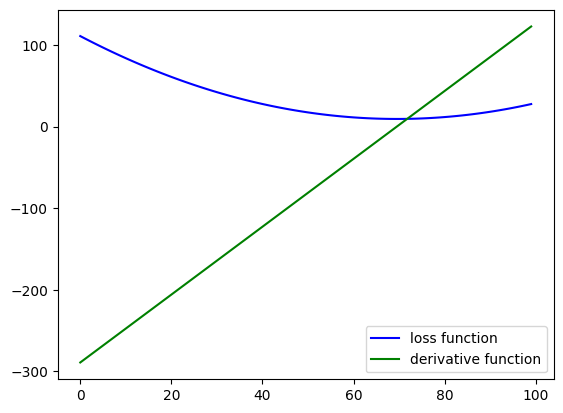

In [20]:
plt.plot(l, 'b', label="loss function")
plt.plot(dldomega_auto, 'g', label="derivative function")

plt.legend()
plt.show()

In [28]:
idx = np.abs(dldomega_auto).argmin()
o[idx]


Array(0.7070707, dtype=float32)